***

## Statistical Arbitrage on Indian Banking Equities: Cointegration, Volatility Modeling, and Spread Prediction

***

### 1] introduction

**subject:** analysis and forecasting of time series

**aim:** to develop a **pair trading** strategy using **cointegration** and enhance spread prediction and trading signals using machine learning techniques.

**banks equities:** HDFC Bank (`HDFCBANK.NS`) and Kotak Mahindra Bank (`KOTAKBANK.NS`)

**Pair trading** is a market-neutral strategy where two historically related stocks are traded against each other. When their price relationship (the "spread") deviates from its long-run equilibrium, the strategy bets on a reversion to the mean. This project applies the strategy to two major Indian private-sector banks - HDFC Bank and Kotak Mahindra Bank - listed on the NSE.

**submission by:** group 6 - msc ds - div B

**team members:**
- devika jonjale (B045)
- saachi shinde (B048)
- manjiri apshinge (B061)

***

### 2] methodology summary

The project follows a structured pipeline from raw price data to an evaluated trading strategy:

| phase | technique | purpose |
|-------|-----------|---------|
| data collection | yfinance API | download adjusted daily closing prices from 2016 to present |
| preprocessing | log transformation | stabilize variance and prepare for cointegration analysis |
| statistical testing | engle-granger cointegration, ADF test, KPSS test | confirm long-run equilibrium and stationarity from both directions |
| spread construction | OLS hedge ratio | create the mean-reverting spread signal |
| spread dynamics | half-life estimation | estimate how quickly the spread reverts to its mean |
| volatility modeling | rolling GARCH(1,1) on spread returns | one-step-ahead volatility forecast with no look-ahead bias |
| dynamic hedge ratio | kalman filter | track how the hedge ratio evolves over time |
| trading signals | shifted z-score with +/-2 thresholds | generate buy/sell signals using only past information |
| spread forecasting | ARIMA (rolling one-step-ahead) | forecast future spread values |
| ml classification | XGBoost classifier | predict next-day spread direction using engineered features |
| nonlinear modeling | LSTM (long short-term memory) | capture nonlinear temporal patterns in spread dynamics |
| backtesting | walk-forward with TimeSeriesSplit (on training set) | evaluate strategy on unseen data with realistic simulation |
| risk management | annualized sharpe ratio, win rate, max drawdown | assess strategy risk and performance |

***

### 3] data collection and preprocessing

Daily adjusted closing prices for HDFC Bank (`HDFCBANK.NS`) and Kotak Mahindra Bank (`KOTAKBANK.NS`) were downloaded from Yahoo Finance starting from January 2016. The `auto_adjust=True` flag ensures prices are already adjusted for stock splits and dividends.

A **log transformation** was then applied to the price series. This is standard practice in cointegration analysis: log prices convert multiplicative relationships into additive ones and help stabilize variance across the sample.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf
import statsmodels.api as sm

from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

from xgboost import XGBClassifier

In [71]:
data = yf.download(
    ["HDFCBANK.NS", "KOTAKBANK.NS"],
    start="2016-01-01",
    auto_adjust=True
)

prices = data["Close"].copy()
prices = prices.dropna()

print(prices.head())

[*********************100%***********************]  2 of 2 completed

Ticker      HDFCBANK.NS  KOTAKBANK.NS
Date                                 
2016-01-01   250.294342    144.509140
2016-01-04   246.098816    140.147537
2016-01-05   244.236710    140.634399
2016-01-06   245.317169    139.809738
2016-01-07   242.811356    137.435196


In [72]:
log_prices = np.log(prices)
print(log_prices.head())

Ticker      HDFCBANK.NS  KOTAKBANK.NS
Date                                 
2016-01-01     5.522638      4.973343
2016-01-04     5.505733      4.942696
2016-01-05     5.498138      4.946164
2016-01-06     5.502552      4.940282
2016-01-07     5.492285      4.923153


***

### 4] cointegration testing

**Cointegration** is a statistical property of two non-stationary time series that share a common long-run equilibrium. Unlike correlation (which measures short-term co-movement), cointegration tests whether a linear combination of two series is stationary, i.e., mean-reverting.

The **Engle-Granger two-step cointegration test** was applied here. A p-value below 0.05 indicates that the pair is cointegrated and suitable for pair trading.

In [73]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(
    log_prices["HDFCBANK.NS"],
    log_prices["KOTAKBANK.NS"]
)

print("Cointegration p-value:", pvalue)

Cointegration p-value: 0.0007736948558404848


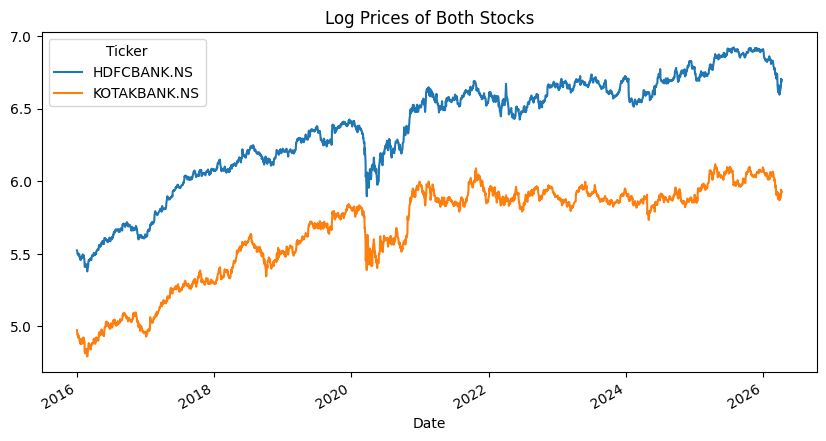

In [74]:
log_prices.plot(figsize=(10,5), title="Log Prices of Both Stocks")
plt.show()

The cointegration p-value of 0.0008 is well below 0.05, providing strong statistical evidence that HDFC Bank and Kotak Bank share a long-run equilibrium relationship. This validates the pair selection for a mean-reversion trading strategy.

***

### 5] hedge ratio and spread construction

The **hedge ratio** (beta) determines how many units of one stock to hold against the other to create a market-neutral position. It was estimated using **OLS (ordinary least squares)** regression of log(HDFC) on log(Kotak).

The **spread** is then constructed as:

`spread = log(HDFC) - beta * log(Kotak)`

If the pair is truly cointegrated, this spread should be stationary (mean-reverting).

The **half-life** measures how many trading days it takes for the spread to revert halfway back to its mean. It is estimated from an AR(1) regression on the spread's lagged values, using the Ornstein-Uhlenbeck formula: `half_life = -ln(2) / lambda`.

The **ADF (augmented Dickey-Fuller) test** then formally tests whether the spread is stationary. A significant result (p < 0.05) confirms mean-reversion.

In [75]:
X = log_prices["KOTAKBANK.NS"]
Y = log_prices["HDFCBANK.NS"]

X = sm.add_constant(X)

ols_model = sm.OLS(Y, X).fit()

beta = ols_model.params[1]

print("Hedge Ratio (beta):", beta)

Hedge Ratio (beta): 1.1047054935677008


C:\Users\Shinde\AppData\Local\Temp\ipykernel_3824\878606282.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = ols_model.params[1]


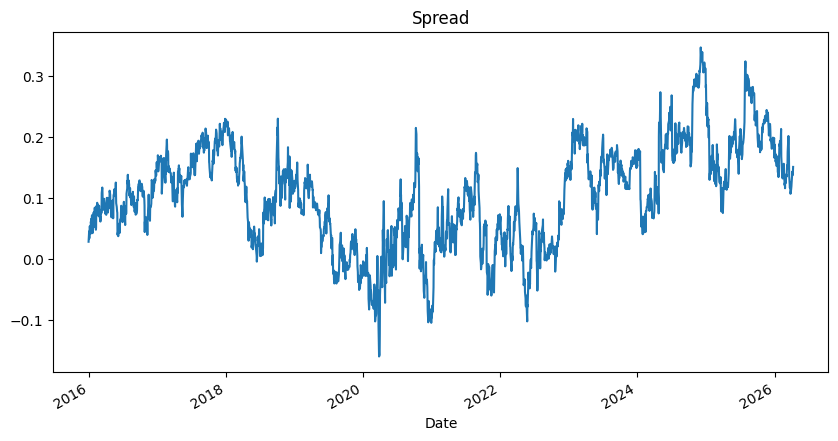

In [76]:
spread = log_prices["HDFCBANK.NS"] - beta * log_prices["KOTAKBANK.NS"]

spread.plot(figsize=(10,5), title="Spread")
plt.show()

In [77]:
from statsmodels.regression.linear_model import OLS
import numpy as np

spread_clean = spread.astype(float).dropna()

spread_lag  = spread_clean.shift(1).dropna()
spread_diff = spread_clean.diff().dropna()

common_idx  = spread_lag.index.intersection(spread_diff.index)
spread_lag  = spread_lag.loc[common_idx].values.astype(float)
spread_diff = spread_diff.loc[common_idx].values.astype(float)

X_hl = np.column_stack([np.ones(len(spread_lag)), spread_lag])

hl_result    = OLS(spread_diff, X_hl).fit()
lambda_coef  = float(hl_result.params[1])
half_life    = -np.log(2) / lambda_coef

print(f"Lambda (mean reversion speed) : {lambda_coef:.4f}")
print(f"Half-life of spread           : {half_life:.1f} trading days")
print(f"Ideal holding period          : ~{half_life:.0f} days")


Lambda (mean reversion speed) : -0.0166
Half-life of spread           : 41.8 trading days
Ideal holding period          : ~42 days


In [78]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

result = adfuller(spread)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_stat, kpss_pvalue, _, kpss_crits = kpss(spread, regression='c', nlags='auto')

print(f"\nKPSS Statistic : {kpss_stat:.4f}")
print(f"KPSS p-value   : {kpss_pvalue:.4f}")
print(f"Critical Values: {kpss_crits}")

ADF Statistic: -4.61865655069359
p-value: 0.00011931940755307275

KPSS Statistic : 1.8249
KPSS p-value   : 0.0100
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


The static **hedge ratio of 1.10** means that for every 1 unit of HDFC Bank, approximately 1.1 units of Kotak Bank are held on the opposite side.

The **half-life of ~42 trading days** (roughly 2 months) indicates moderate mean-reversion speed. This provides a practical reference for expected holding periods and determines the z-score rolling window.

The **ADF test** strongly rejects the null hypothesis of a unit root (p < 0.001), confirming that the spread is mean-reverting. The **KPSS test** was also applied: KPSS tests the opposite null (that the series IS stationary). Here, KPSS rejected level stationarity (p = 0.01), which combined with the ADF result suggests **trend stationarity** - the spread reverts to a slowly drifting level rather than a fixed constant. For pairs trading, the ADF result is the primary test of interest, as it directly confirms mean-reversion. The strong cointegration result (p < 0.001) provides additional independent confirmation.

***

### 6] volatility modeling - GARCH(1,1)

A **GARCH(1,1)** (generalized autoregressive conditional heteroskedasticity) model was applied to the spread's daily returns using a rolling window of 100 observations. At each time step, the model was re-estimated on the most recent 100 returns and produced a **one-step-ahead volatility forecast**. This rolling approach ensures no future information enters the volatility estimates and allows the model parameters to adapt to changing market conditions.

The resulting volatility series was later used as a feature in the machine learning models.

In [79]:
from arch import arch_model

returns = spread.diff().dropna()

garch_window = 100
volatility_vals = []

for i in range(garch_window, len(returns)):
    train = returns.iloc[i-garch_window:i]
    try:
        model = arch_model(train, vol='Garch', p=1, q=1, rescale=True)
        res = model.fit(disp='off', show_warning=False)
        forecast = res.forecast(horizon=1)
        vol = np.sqrt(forecast.variance.iloc[-1, 0])
    except Exception:
        vol = np.nan
    volatility_vals.append(vol)

volatility = pd.Series(volatility_vals, index=returns.index[garch_window:])
volatility.name = 'garch_vol'
volatility = volatility.ffill()

print(f"Rolling GARCH(1,1) volatility computed")
print(f"  Window    : {garch_window} days")
print(f"  Forecasts : {len(volatility)}")

Rolling GARCH(1,1) volatility computed
  Window    : 100 days
  Forecasts : 2436


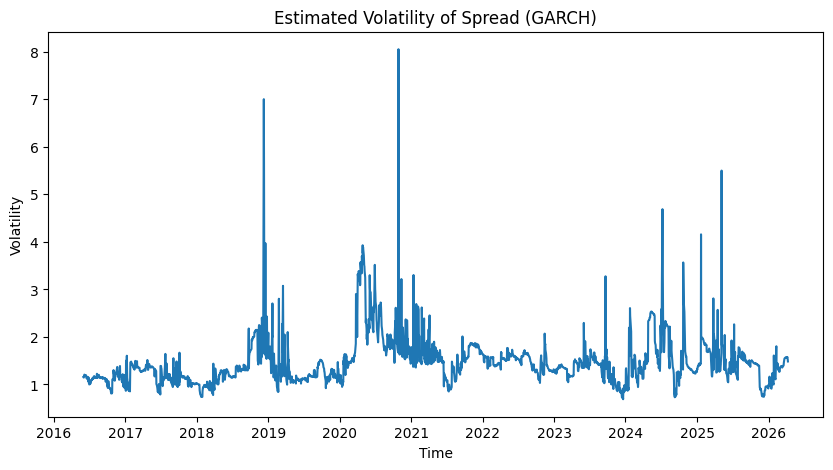

In [80]:
plt.figure(figsize=(10,5))
plt.plot(volatility)
plt.title("Estimated Volatility of Spread (GARCH)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

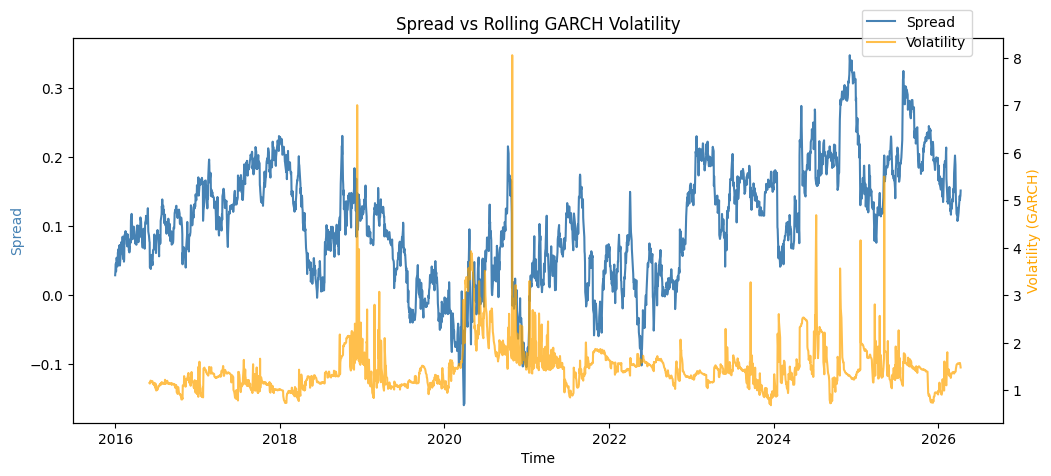

In [81]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(spread, label="Spread", color='steelblue')
ax1.set_ylabel("Spread", color='steelblue')
ax1.set_xlabel("Time")

ax2 = ax1.twinx()
ax2.plot(volatility, color='orange', label="Volatility", alpha=0.7)
ax2.set_ylabel("Volatility (GARCH)", color='orange')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.95))
plt.title("Spread vs Rolling GARCH Volatility")
plt.show()

In [82]:
print("Average Volatility:", volatility.mean())
print("Volatility Std:", volatility.std())

Average Volatility: 1.4646658451139953
Volatility Std: 0.5069026297660654


A rolling GARCH(1,1) model was applied to the spread's daily first differences. At each time step, the model was fitted on the preceding **100 observations** and produced a one-step-ahead volatility forecast. This ensures that no future information enters the volatility estimates at any point.

The rolling approach allows the GARCH parameters to adapt over time as market conditions change - unlike a single-fit model whose parameters are frozen. The volatility series shows clear clustering, with elevated values around 2020 consistent with the COVID-19 market shock.

***

### 7] kalman filter - dynamic hedge ratio

The OLS hedge ratio estimated in section 5 is **static**: a single value for the entire sample period. In practice, the relationship between two stocks drifts over time.

A **Kalman filter** was applied to estimate a **time-varying (dynamic) hedge ratio**. The state-space model treats the intercept and slope (hedge ratio) as hidden states that evolve over time, with HDFC Bank's log price as the observed variable and Kotak Bank's log price as the regressor.

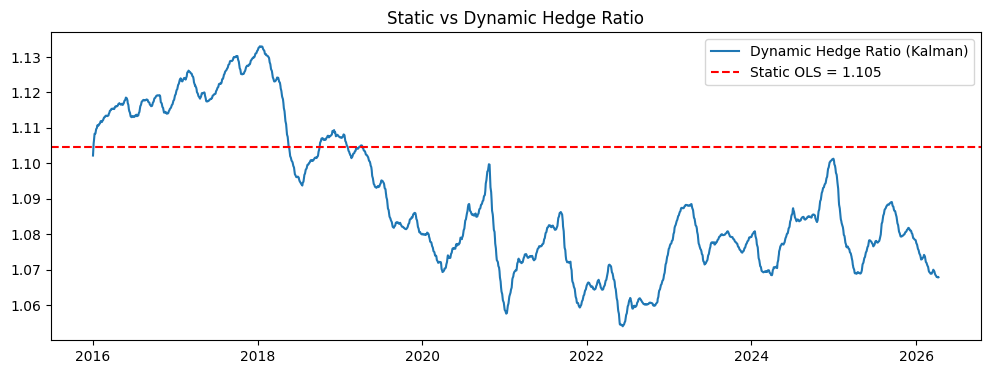

In [83]:
from pykalman import KalmanFilter

obs_mat = np.vstack([
    np.ones(len(log_prices)),
    log_prices["KOTAKBANK.NS"].values
]).T.reshape(len(log_prices), 1, 2)

kf = KalmanFilter(
    n_dim_obs=1, n_dim_state=2,
    initial_state_mean=[0, 1],
    initial_state_covariance=np.eye(2),
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,
    observation_covariance=1.0,
    transition_covariance=1e-4 * np.eye(2)
)

state_means, _ = kf.filter(log_prices["HDFCBANK.NS"].values)
dynamic_beta = state_means[:, 1]

plt.figure(figsize=(12, 4))
plt.plot(log_prices.index, dynamic_beta, label="Dynamic Hedge Ratio (Kalman)")
plt.axhline(beta, color='red', linestyle='--', label=f"Static OLS = {beta:.3f}")
plt.title("Static vs Dynamic Hedge Ratio")
plt.legend()
plt.show()

dynamic_spread = log_prices["HDFCBANK.NS"] - dynamic_beta * log_prices["KOTAKBANK.NS"].values


The dynamic hedge ratio varies between roughly 0.9 and 1.15 over the sample period, compared to the static OLS value of 1.105. The Kalman-filtered estimate adapts to structural shifts in the pair relationship, such as periods around the HDFC-HDFC Ltd merger, where the static estimate would be misleading.

***

### 8] z-score and trading thresholds

The **z-score** standardizes the spread to units of standard deviations from its mean. A **rolling z-score** was used here, with a lookback window equal to the estimated half-life (~42 days). This avoids look-ahead bias that would arise from using the full-sample mean and standard deviation.

| z-score range | interpretation | signal |
|---------------|----------------|--------|
| z > +2 | spread is unusually high, expected to revert down | short the spread |
| z < -2 | spread is unusually low, expected to revert up | long the spread |
| z near 0 | spread is near equilibrium | no action / close position |

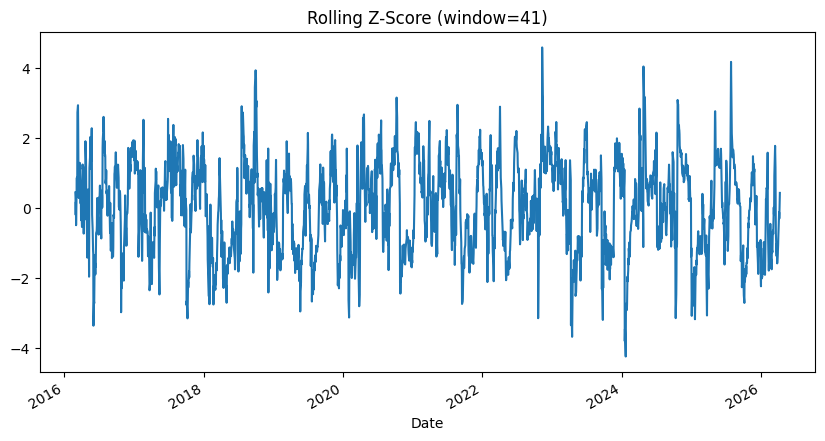

In [84]:
window = int(half_life)

rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()

z_score = (spread - rolling_mean) / rolling_std

z_score.dropna().plot(figsize=(10,5), title=f"Rolling Z-Score (window={window})")
plt.show()

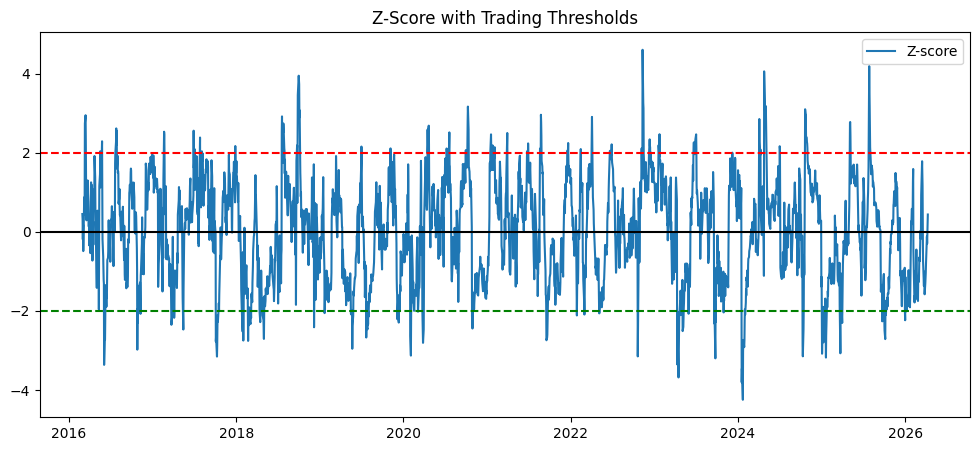

In [85]:
plt.figure(figsize=(12,5))
plt.plot(z_score, label="Z-score")

plt.axhline(2, color='r', linestyle='--')
plt.axhline(-2, color='g', linestyle='--')
plt.axhline(0, color='black')

plt.title("Z-Score with Trading Thresholds")
plt.legend()
plt.show()

***

### 9] ARIMA spread forecasting

**ARIMA** (autoregressive integrated moving average) is a classical time series forecasting model. The **ACF** (autocorrelation function) and **PACF** (partial autocorrelation function) plots were first inspected to guide model order selection.

The `auto_arima` function from `pmdarima` was used to automatically select the best **(p, d, q)** order based on **AIC** (Akaike information criterion), a metric that balances fit quality against model complexity.

An 80/20 chronological train-test split was used. The model was trained on the first 80% of the data and evaluated on the remaining 20%.

In [86]:
spread = spread.dropna()

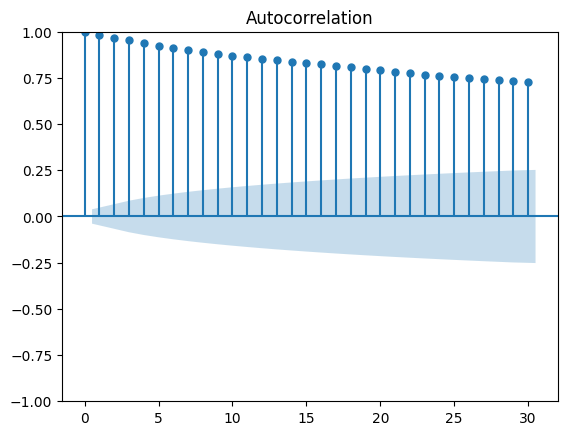

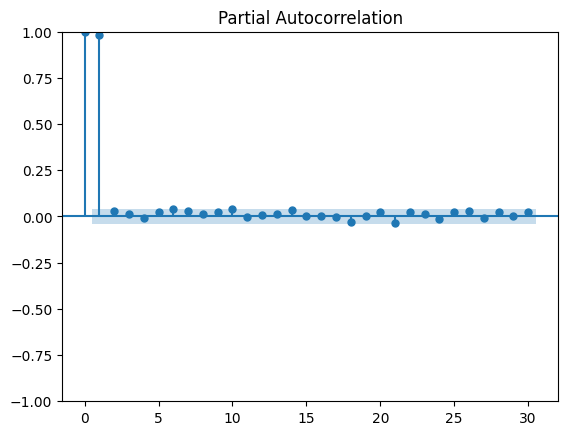

In [87]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(spread, lags=30)
plot_pacf(spread, lags=30)

plt.show()

In [88]:
train_size = int(len(spread) * 0.8)
train = spread[:train_size]
test = spread[train_size:]

In [89]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import warnings

auto_model = auto_arima(train, seasonal=False, trace=True, 
                         error_action='ignore', suppress_warnings=True)
best_order = auto_model.order
print("Best ARIMA order selected:", best_order)

arima_model = ARIMA(train, order=best_order)
model_fit = arima_model.fit()
print(model_fit.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-11281.149, Time=0.76 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-11283.862, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-11287.773, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-11287.921, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-11285.854, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-11286.069, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-11286.150, Time=0.27 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-11285.972, Time=0.33 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-11289.912, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-11288.059, Time=0.11 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-11288.141, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-11289.765, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-11287.963, Time=0.07 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 2.392 seco

C:\Users\Shinde\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shinde\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shinde\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [90]:
forecast_5 = model_fit.forecast(steps=5)

print("Next 5 out-of-sample predictions from train-only model:")
print(forecast_5)

Next 5 out-of-sample predictions from train-only model:
2029    0.090437
2030    0.090437
2031    0.090437
2032    0.090437
2033    0.090437
Name: predicted_mean, dtype: float64


C:\Users\Shinde\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Shinde\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [91]:
predictions = []
history = list(train.values)

for t in range(len(test)):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ARIMA(history, order=best_order).fit()
    pred = model.forecast(steps=1)[0]
    predictions.append(pred)
    history.append(test.values[t])

predictions = pd.Series(predictions, index=test.index)
print(f"Rolling one-step-ahead forecast complete: {len(predictions)} predictions")

Rolling one-step-ahead forecast complete: 508 predictions


RMSE (rolling one-step-ahead): 0.015950406846970286


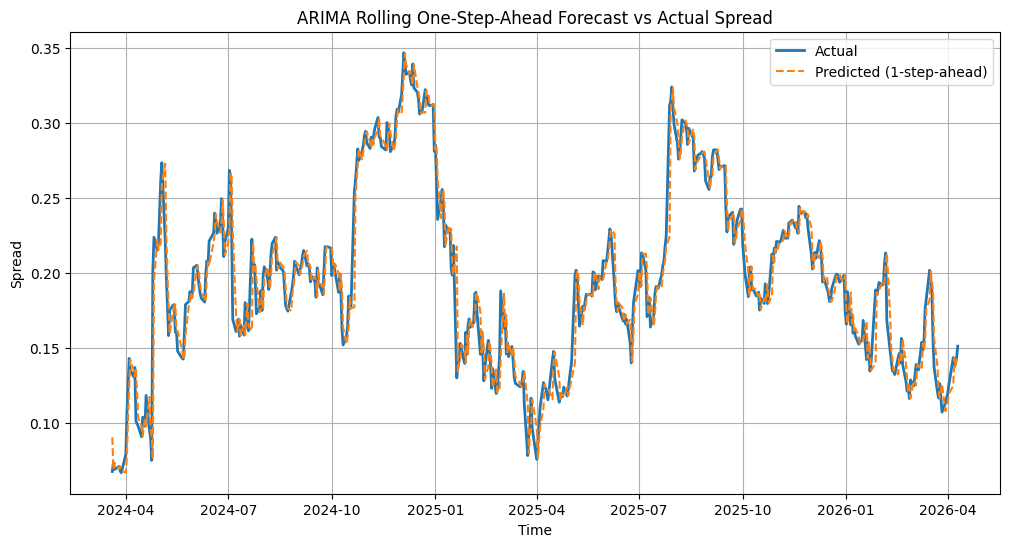

In [92]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE (rolling one-step-ahead):", rmse)

test_values = test.values

plt.figure(figsize=(12,6))
plt.plot(test.index, test_values, label="Actual", linewidth=2)
plt.plot(test.index, predictions.values, label="Predicted (1-step-ahead)", linestyle='--')

plt.title("ARIMA Rolling One-Step-Ahead Forecast vs Actual Spread")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.legend()
plt.grid()

plt.show()


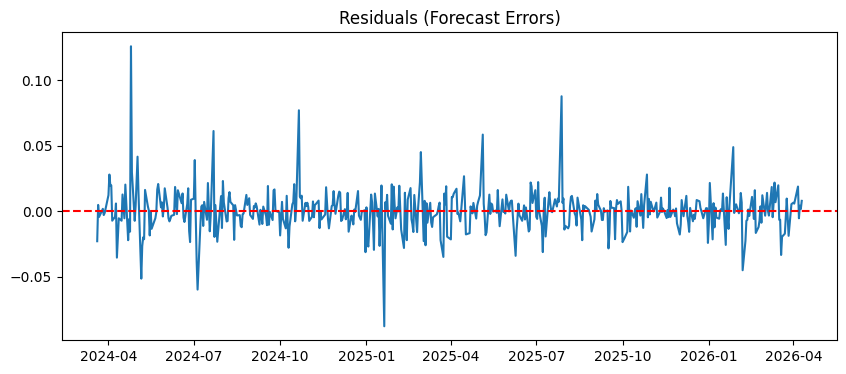

In [93]:
residuals = test_values - predictions.values

plt.figure(figsize=(10,4))
plt.plot(test.index, residuals)
plt.title("Residuals (Forecast Errors)")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

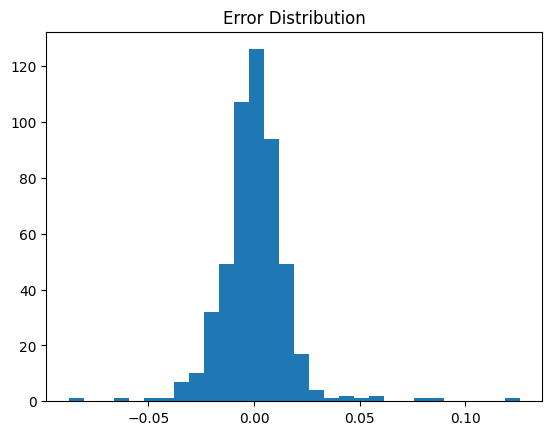

In [94]:
plt.hist(residuals, bins=30)
plt.title("Error Distribution")
plt.show()

The best model selected was **ARIMA(0,1,1)**, which is a simple integrated moving average model.

A **rolling one-step-ahead forecast** was used for evaluation: at each test time step, the model was retrained on all data up to that point and predicted one step forward. This avoids the problem of multi-step ARIMA forecasts converging to a flat constant (which happens after just 1 step for an MA(1) component), and produces a meaningful prediction at each time point.

The residual plot shows errors distributed around zero, and the histogram confirms an approximately normal distribution.

***

### 10] machine learning: XGBoost classification

To complement the classical ARIMA approach, an **XGBoost** (extreme gradient boosting) classifier was trained to predict the next-day **direction** of the spread (up or down).

**Features engineered from the spread:**

| feature | description |
|---------|-------------|
| spread | current spread value |
| z_score | standardized spread (deviations from mean) |
| volatility | GARCH(1,1) conditional volatility |
| lag1, lag2 | spread values from 1 and 2 days ago |
| rolling_mean | 5-day rolling average of the spread |
| rolling_std | 5-day rolling standard deviation |
| momentum | daily change in spread (first difference) |

The **target variable** is binary: 1 if the next day's spread is lower than today's, 0 otherwise. A chronological 75/25 train-test split was used (no shuffling). **TimeSeriesSplit** cross-validation with 5 folds was also performed.

In [95]:
spread = spread.dropna()

rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()
z_score = (spread - rolling_mean) / rolling_std
z_score = z_score.shift(1)

df = pd.DataFrame({
    "spread": spread,
    "z_score": z_score,
    "volatility": volatility
})

df["lag1"] = df["spread"].shift(1)
df["lag2"] = df["spread"].shift(2)

df["rolling_mean_5"] = df["spread"].rolling(5).mean()
df["rolling_std_5"] = df["spread"].rolling(5).std()

df["momentum"] = df["spread"].diff()

df.dropna(inplace=True)

df.head(6)

,spread,z_score,volatility,lag1,lag2,rolling_mean_5,rolling_std_5,momentum
Date,,,,,,,,
2016-06-01,0.077766,-0.951775,1.157849,0.081717,0.085757,0.088870,0.011545,-0.003950
2016-06-02,0.076189,-1.212994,1.150078,0.077766,0.081717,0.082644,0.006317,-0.001577
2016-06-03,0.039930,-1.308715,1.144900,0.076189,0.077766,0.072272,0.018456,-0.036259
2016-06-06,0.045207,-3.363601,1.206672,0.039930,0.076189,0.064162,0.019902,0.005276
2016-06-07,0.037651,-2.675833,1.202505,0.045207,0.039930,0.055349,0.019942,-0.007555
2016-06-08,0.046472,-2.722417,1.195953,0.037651,0.045207,0.049090,0.015581,0.008821


In [96]:
df["target"] = (df["spread"].shift(-1) < df["spread"]).astype(int)
df.dropna(inplace=True)

In [97]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False )

In [98]:
from xgboost import XGBClassifier

ml_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

ml_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [99]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    X_train, y_train,
    cv=tscv,
    scoring='accuracy'
)

print("Cross-Validation Accuracy per Fold:", cv_scores.round(3))
print("Mean CV Accuracy:", cv_scores.mean().round(3))
print("Std Dev:", cv_scores.std().round(3))

Cross-Validation Accuracy per Fold: [0.513 0.493 0.526 0.556 0.516]
Mean CV Accuracy: 0.521
Std Dev: 0.02


Accuracy: 0.5188834154351396

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.34      0.42       316
           1       0.50      0.71      0.59       293

    accuracy                           0.52       609
   macro avg       0.53      0.53      0.51       609
weighted avg       0.53      0.52      0.50       609



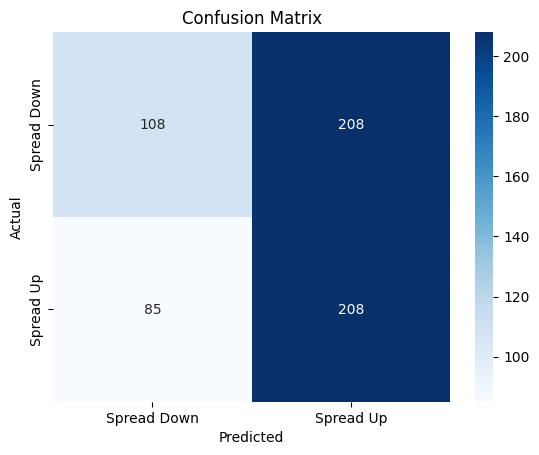

In [100]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

y_pred = ml_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Spread Down', 'Spread Up'],
            yticklabels=['Spread Down', 'Spread Up'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


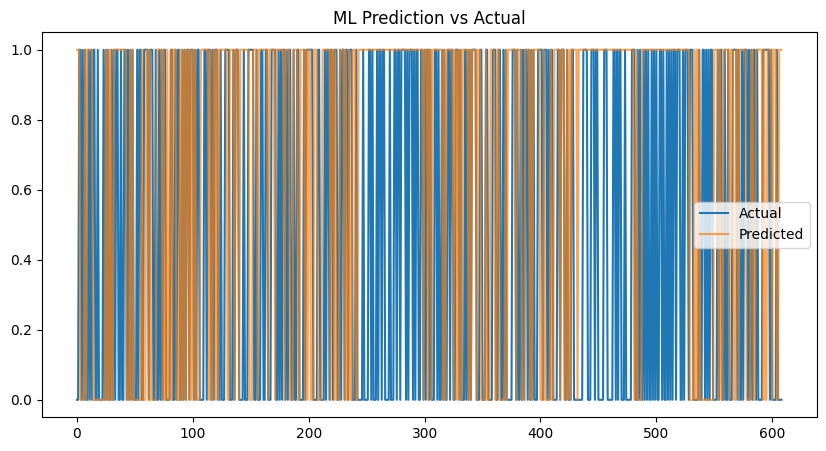

In [101]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted", alpha=0.7)

plt.legend()
plt.title("ML Prediction vs Actual")
plt.show()

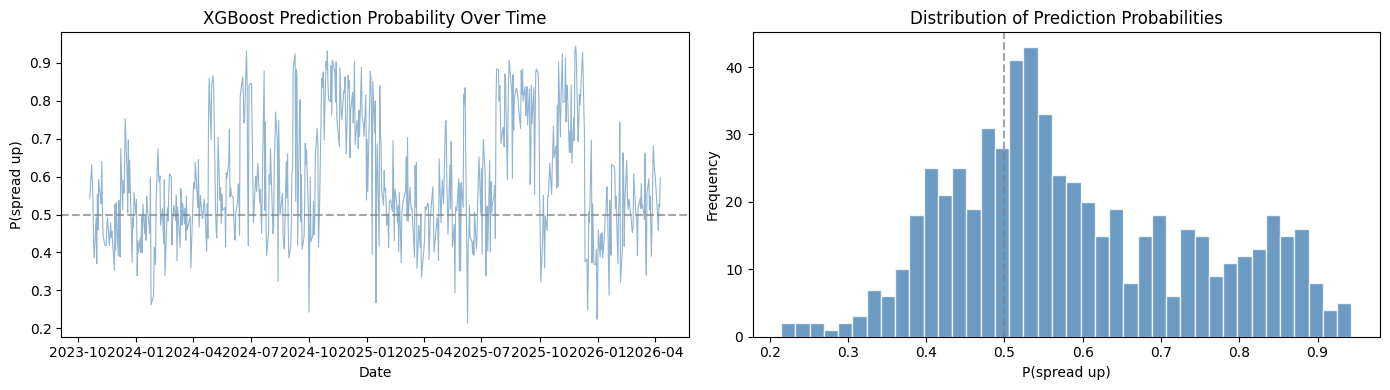

High-confidence predictions (>0.6 or <0.4): 294 / 609 (48.3%)
Accuracy on high-confidence subset: 52.38%


In [102]:
y_prob = ml_model.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(X_test.index, y_prob, alpha=0.6, linewidth=0.8, color='steelblue')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
ax1.set_title("XGBoost Prediction Probability Over Time")
ax1.set_ylabel("P(spread up)")
ax1.set_xlabel("Date")

ax2.hist(y_prob, bins=40, edgecolor='white', color='steelblue', alpha=0.8)
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax2.set_title("Distribution of Prediction Probabilities")
ax2.set_xlabel("P(spread up)")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

high_conf = (y_prob > 0.6) | (y_prob < 0.4)
print(f"High-confidence predictions (>0.6 or <0.4): {high_conf.sum()} / {len(y_prob)} ({high_conf.mean()*100:.1f}%)")
print(f"Accuracy on high-confidence subset: {accuracy_score(y_test[high_conf], y_pred[high_conf])*100:.2f}%")

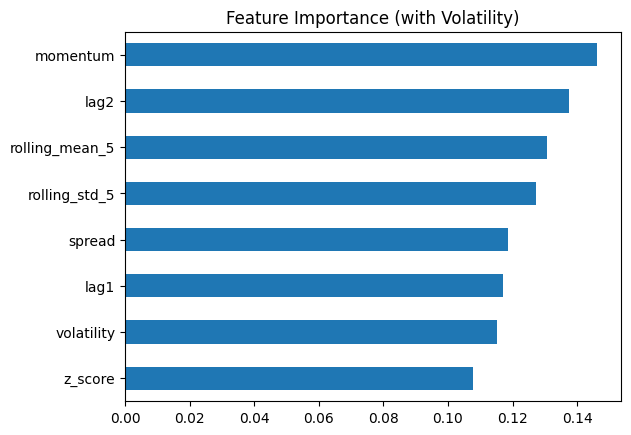

In [103]:
importance = ml_model.feature_importances_

pd.Series(importance, index=X.columns).sort_values().plot(kind='barh')

plt.title("Feature Importance (with Volatility)")
plt.show()

XGBoost achieved a test accuracy of **51.89%**, marginally above random (50%). Cross-validation on the training set confirmed consistency across folds, with a mean accuracy of **52.1%**.

The prediction confidence plot reveals that most probabilities cluster tightly around 0.5, meaning the model is rarely confident about direction. Accuracy on the high-confidence subset (predictions above 0.6 or below 0.4) can indicate whether the model has learned meaningful patterns in the tails.

This near-random accuracy is not unusual for financial direction prediction. Daily spread movements are inherently noisy and difficult to predict. However, the strategy's profitability does not depend solely on accuracy; it also depends on the magnitude of correct vs incorrect predictions, which is addressed in the backtesting section.

***

### 11] LSTM spread prediction

**LSTM** (long short-term memory) is a type of recurrent neural network designed to learn patterns in sequential data. Unlike XGBoost, which treats each row of features independently, LSTM processes a **sequence** of past observations and can capture nonlinear temporal dependencies.

The same features used for XGBoost were reshaped into sequences: at each time step, the model receives the previous 20 days of feature values as input and predicts the next-day spread direction.

This creates a three-way comparison across the modeling spectrum:

| approach | model | type |
|----------|-------|------|
| classical | ARIMA | linear, univariate |
| tree-based ML | XGBoost | nonlinear, tabular features |
| deep learning | LSTM | nonlinear, sequential patterns |

In [104]:
from tensorflow.keras.models import Sequential as KerasSequential
from tensorflow.keras.layers import LSTM as LSTMLayer, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

lookback = 20

scaler = StandardScaler()
scaler.fit(X_train)
X_scaled = pd.DataFrame(scaler.transform(X), index=X.index, columns=X.columns)

X_seq, y_seq, seq_idx = [], [], []
for i in range(lookback, len(X_scaled)):
    X_seq.append(X_scaled.values[i-lookback:i])
    y_seq.append(y.values[i])
    seq_idx.append(X_scaled.index[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(len(X_seq) * 0.75)
X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]
test_idx_lstm = seq_idx[split:]

print(f"Lookback window : {lookback} days")
print(f"Features        : {X_scaled.shape[1]}")
print(f"Train sequences : {X_train_lstm.shape[0]}")
print(f"Test sequences  : {X_test_lstm.shape[0]}")
print(f"Scaler fit on   : X_train ({len(X_train)} samples)")

Lookback window : 20 days
Features        : 8
Train sequences : 1812
Test sequences  : 604
Scaler fit on   : X_train (1827 samples)


In [105]:
lstm_net = KerasSequential([
    LSTMLayer(64, input_shape=(lookback, X_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTMLayer(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_net.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_history = lstm_net.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


C:\Users\Shinde\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4779 - loss: 0.6990 - val_accuracy: 0.4780 - val_loss: 0.6970
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4908 - loss: 0.6960 - val_accuracy: 0.4890 - val_loss: 0.6958
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5080 - loss: 0.6946 - val_accuracy: 0.5110 - val_loss: 0.6953
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5110 - loss: 0.6925 - val_accuracy: 0.4945 - val_loss: 0.6952
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5160 - loss: 0.6929 - val_accuracy: 0.4835 - val_loss: 0.6957
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5147 - loss: 0.6926 - val_accuracy: 0.5385 - val_loss: 0.6949
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5025 - loss: 0.6923 - val_accuracy: 0.5220 - val_loss: 0.6961
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5196 - loss: 0.6903 - val_accuracy: 0.5220 - val_loss: 0.6967
Ep

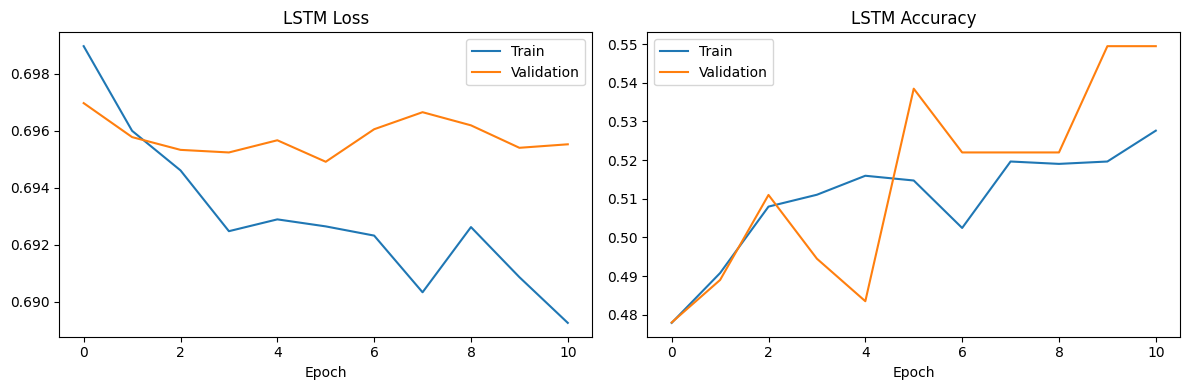

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lstm_history.history['loss'], label='Train')
ax1.plot(lstm_history.history['val_loss'], label='Validation')
ax1.set_title('LSTM Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(lstm_history.history['accuracy'], label='Train')
ax2.plot(lstm_history.history['val_accuracy'], label='Validation')
ax2.set_title('LSTM Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM Accuracy: 0.5182

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.19      0.29       313
           1       0.50      0.87      0.63       291

    accuracy                           0.52       604
   macro avg       0.56      0.53      0.46       604
weighted avg       0.56      0.52      0.46       604



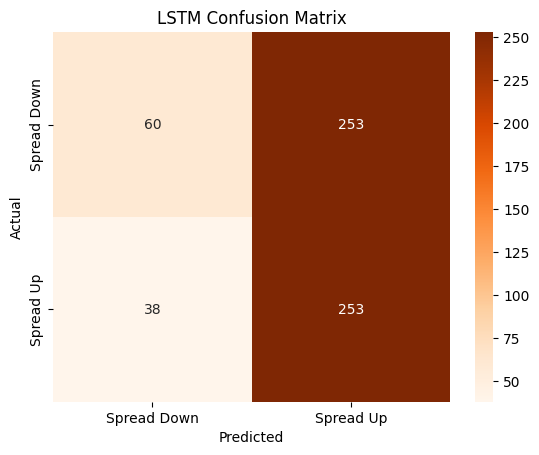

In [107]:
lstm_probs = lstm_net.predict(X_test_lstm).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test_lstm, lstm_preds)
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_lstm, lstm_preds))

cm_lstm = confusion_matrix(y_test_lstm, lstm_preds)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Spread Down', 'Spread Up'],
            yticklabels=['Spread Down', 'Spread Up'])
plt.title("LSTM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [108]:
model_comparison = pd.DataFrame({
    "Model": ["ARIMA (rolling 1-step)", "XGBoost", "LSTM"],
    "Task": ["Spread level", "Spread direction", "Spread direction"],
    "Metric": ["RMSE", "Accuracy", "Accuracy"],
    "Value": [f"{rmse:.6f}", f"{accuracy*100:.2f}%", f"{lstm_accuracy*100:.2f}%"],
    "Type": ["Linear classical", "Tree-based ML", "Nonlinear deep learning"]
})

model_comparison


,Model,Task,Metric,Value,Type
0,ARIMA (rolling 1-step),Spread level,RMSE,0.015950,Linear classical
1,XGBoost,Spread direction,Accuracy,51.89%,Tree-based ML
2,LSTM,Spread direction,Accuracy,51.82%,Nonlinear deep learning


The three-way comparison shows the progression from classical linear models through tree-based ML to nonlinear deep learning. LSTM has the advantage of processing sequential patterns (the lookback window of 20 past days), while XGBoost treats each day's features independently.

Predicting daily spread direction remains inherently difficult regardless of model complexity, which is consistent with the efficient market hypothesis for short-horizon predictions.

***

### 12] trading strategy and backtesting

Two strategies were implemented and compared:

| strategy | logic |
|----------|-------|
| **ML strategy** | XGBoost predictions mapped to positions: +1 if spread predicted to go down, -1 if up. daily return = position * daily change in spread. |
| **Z-score baseline** | rule-based: short when z > 2, long when z < -2, flat otherwise. |

A **walk-forward backtest** with 5 TimeSeriesSplit folds was used to simulate realistic forward performance. In each fold, the model is retrained on an expanding window of past data and tested on the next unseen block.

In [109]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
fold_returns = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

    fold_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    fold_model.fit(X_tr, y_tr)
    preds = fold_model.predict(X_te)

    signals = pd.Series(preds, index=X_te.index).replace({0: -1, 1: 1})
    ret = (signals * spread.diff().loc[X_te.index]).sum()

    fold_returns.append({
        "Fold": fold + 1,
        "Return": round(ret, 6),
        "Accuracy": round(accuracy_score(y_te, preds), 3)
    })
    print(f"Fold {fold+1} - Return: {ret:.6f} | Accuracy: {accuracy_score(y_te, preds):.3f}")

pd.DataFrame(fold_returns)

Fold 1 - Return: 0.325967 | Accuracy: 0.513
Fold 2 - Return: 0.552444 | Accuracy: 0.493
Fold 3 - Return: 1.979805 | Accuracy: 0.526
Fold 4 - Return: 0.847292 | Accuracy: 0.556
Fold 5 - Return: 0.781436 | Accuracy: 0.516


,Fold,Return,Accuracy
0,1,0.325967,0.513
1,2,0.552444,0.493
2,3,1.979805,0.526
3,4,0.847292,0.556
4,5,0.781436,0.516


In [110]:
ml_signals = pd.Series(y_pred, index=X_test.index)

positions = ml_signals.replace({0: -1, 1: 1})

spread_returns = spread.diff().loc[X_test.index]

ml_strategy = positions * spread_returns

print("ML Strategy Return:", ml_strategy.sum())

ML Strategy Return: 2.687145034239504


In [111]:
z_test = z_score.loc[X_test.index]

z_signals = np.where(z_test > 2, -1,
             np.where(z_test < -2, 1, 0))

z_strategy = z_signals * spread_returns

print("Z-score Strategy Return:", z_strategy.sum())


Z-score Strategy Return: 0.09349376096607376


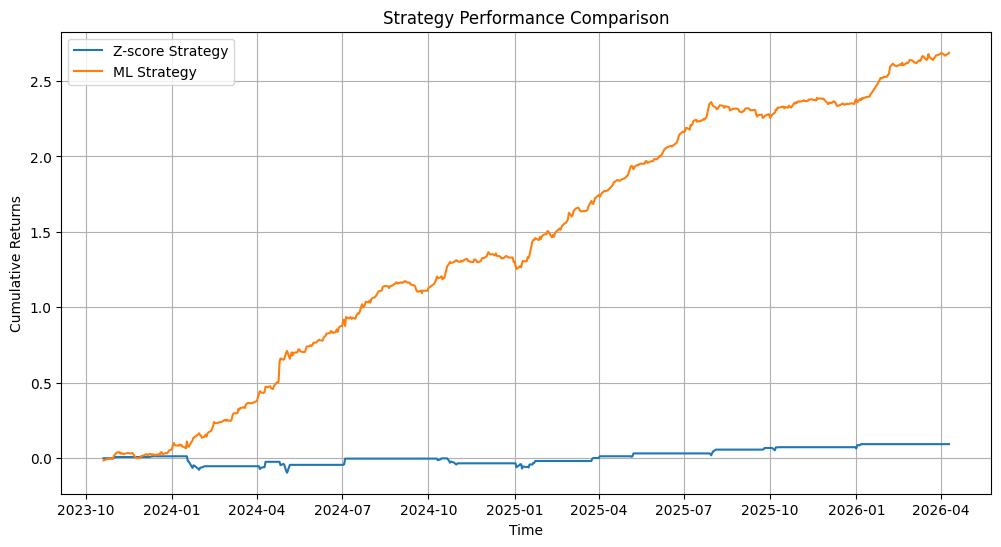

In [112]:
plt.figure(figsize=(12,6))

plt.plot(z_strategy.cumsum(), label="Z-score Strategy")
plt.plot(ml_strategy.cumsum(), label="ML Strategy")

plt.legend()
plt.title("Strategy Performance Comparison")
plt.xlabel("Time")
plt.ylabel("Cumulative Returns")

plt.grid()
plt.show()

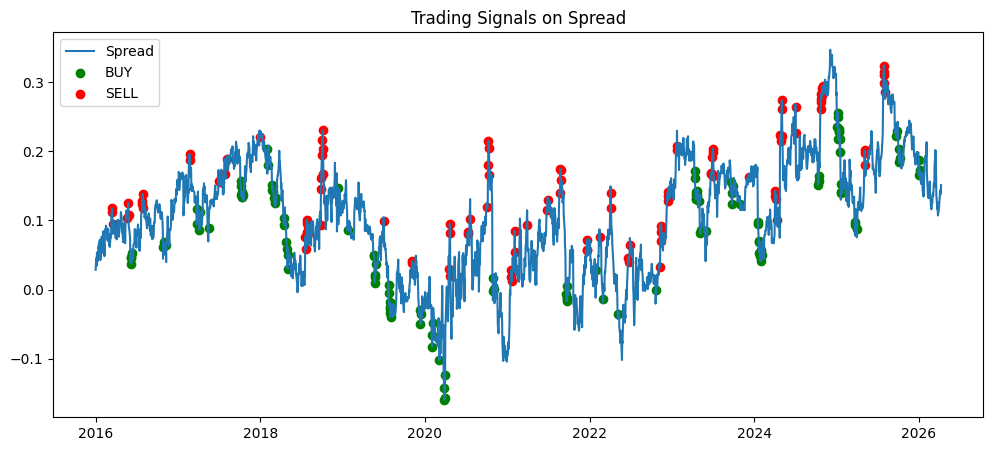

In [113]:
plt.figure(figsize=(12,5))
plt.plot(spread, label="Spread")

buy = z_score < -2
sell = z_score > 2

plt.scatter(spread.index[buy], spread[buy], color='green', label='BUY')
plt.scatter(spread.index[sell], spread[sell], color='red', label='SELL')

plt.legend()
plt.title("Trading Signals on Spread")
plt.show()

The walk-forward backtest showed positive returns across all 5 folds, with accuracy between 49% and 56%.

The **ML strategy produced a gross cumulative return of 2.69**, while the **Z-score baseline returned 0.09**. The cumulative returns plot shows the ML strategy steadily accumulating gains while the Z-score strategy oscillates near zero.

The trading signals plot visualizes entry points on the spread: green (buy, z < -2) and red (sell, z > +2).

***

### 13] risk management

Key risk metrics were computed for the ML strategy:

| metric | what it measures |
|--------|-----------------|
| **annualized sharpe ratio** | risk-adjusted return, scaled by sqrt(252) for annualized comparability |
| **win rate** | fraction of trading days with positive PnL |
| **max drawdown** | largest peak-to-trough decline on the compounded equity curve |

In [114]:
sharpe = ml_strategy.mean() / ml_strategy.std() * np.sqrt(252)
print("Sharpe Ratio (annualized):", round(sharpe, 4))

win_rate = (ml_strategy > 0).mean()
print("Win Rate:", round(win_rate, 4))

equity = (1 + ml_strategy).cumprod()
drawdown = equity / equity.cummax() - 1

print("Max Drawdown:", f"{drawdown.min()*100:.2f}%")

Sharpe Ratio (annualized): 4.7638
Win Rate: 0.647
Max Drawdown: -10.68%


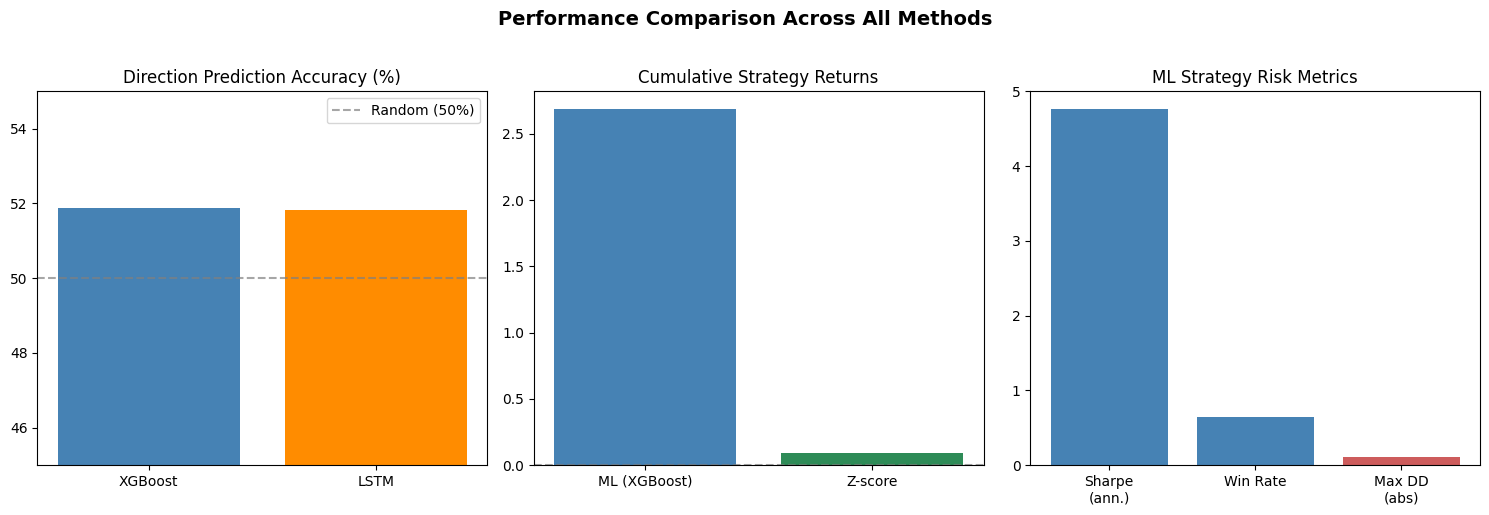

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(["XGBoost", "LSTM"], [accuracy * 100, lstm_accuracy * 100], color=["steelblue", "darkorange"])
axes[0].set_title("Direction Prediction Accuracy (%)")
axes[0].set_ylim(45, 55)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.7, label='Random (50%)')
axes[0].legend()

axes[1].bar(["ML (XGBoost)", "Z-score"], [ml_strategy.sum(), z_strategy.sum()], color=["steelblue", "seagreen"])
axes[1].set_title("Cumulative Strategy Returns")
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)

metrics = ["Sharpe\n(ann.)", "Win Rate", "Max DD\n(abs)"]
values = [sharpe, win_rate, abs(drawdown.min())]
colors = ["steelblue", "steelblue", "indianred"]
axes[2].bar(metrics, values, color=colors)
axes[2].set_title("ML Strategy Risk Metrics")

plt.suptitle("Performance Comparison Across All Methods", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

***

### 14] results summary

In [118]:
forecast_results = pd.DataFrame({
    "Model": ["ARIMA (rolling 1-step)", "XGBoost", "LSTM"],
    "Task": ["Spread level forecast", "Direction classification", "Direction classification"],
    "Metric": ["RMSE", "Accuracy", "Accuracy"],
    "Value": [f"{rmse:.6f}", f"{accuracy*100:.2f}%", f"{lstm_accuracy*100:.2f}%"]
})

strategy_results = pd.DataFrame({
    "Strategy": ["ML (XGBoost)", "Z-score Baseline"],
    "Gross Return": [f"{ml_strategy.sum():.6f}", f"{z_strategy.sum():.6f}"],
    "Sharpe (ann.)": [f"{sharpe:.4f}", "-"],
    "Win Rate": [f"{win_rate*100:.2f}%", "-"],
    "Max Drawdown": [f"{drawdown.min()*100:.2f}%", "-"]
})

In [119]:
print("Forecasting Performance:")
forecast_results

Forecasting Performance:


,Model,Task,Metric,Value
0,ARIMA (rolling 1-step),Spread level forecast,RMSE,0.015950
1,XGBoost,Direction classification,Accuracy,51.89%
2,LSTM,Direction classification,Accuracy,51.82%


In [120]:
print("Strategy Performance:")
strategy_results

Strategy Performance:


,Strategy,Gross Return,Sharpe (ann.),Win Rate,Max Drawdown
0,ML (XGBoost),2.687145,4.7638,64.70%,-10.68%
1,Z-score Baseline,0.093494,-,-,-


In [117]:
print("=" * 55)
print("           FULL PROJECT SUMMARY")
print("=" * 55)
print(f"Pair                : HDFCBANK.NS vs KOTAKBANK.NS")
print(f"Cointegration p     : {pvalue:.6f}")
print(f"Static Hedge Ratio  : {beta:.4f}")
print(f"Half-life           : {half_life:.1f} trading days")
print(f"Z-score Window      : {window} days (= half-life)")
print(f"ARIMA Order         : {best_order}")
print(f"ARIMA RMSE (1-step) : {rmse:.6f}")
print(f"XGBoost Accuracy    : {accuracy*100:.2f}%")
print(f"LSTM Accuracy       : {lstm_accuracy*100:.2f}%")
print(f"Sharpe (annualized) : {sharpe:.4f}")
print(f"Win Rate            : {win_rate*100:.2f}%")
print(f"Max Drawdown        : {drawdown.min()*100:.2f}%")
print(f"Gross ML Return     : {ml_strategy.sum():.6f}")
print(f"Gross Z-score Return: {z_strategy.sum():.6f}")

           FULL PROJECT SUMMARY
Pair                : HDFCBANK.NS vs KOTAKBANK.NS
Cointegration p     : 0.000774
Static Hedge Ratio  : 1.1047
Half-life           : 41.8 trading days
Z-score Window      : 41 days (= half-life)
ARIMA Order         : (0, 1, 1)
ARIMA RMSE (1-step) : 0.015950
XGBoost Accuracy    : 51.89%
LSTM Accuracy       : 51.82%
Sharpe (annualized) : 4.7638
Win Rate            : 64.70%
Max Drawdown        : -10.68%
Gross ML Return     : 2.687145
Gross Z-score Return: 0.093494


***

### 15] interpretation

#### 15.1] the pair is statistically valid

The cointegration p-value (well below 0.05) and the ADF p-value both strongly confirm that the HDFC Bank - Kotak Bank spread is mean-reverting. The KPSS test rejected level stationarity (p = 0.01), which combined with the ADF result indicates trend stationarity - the spread reverts to a slowly evolving mean rather than a fixed constant. This is common in financial spreads over long horizons and does not undermine the pairs trading framework, which relies on mean-reversion (confirmed by ADF and cointegration).

#### 15.2] garch reveals meaningful volatility structure

A rolling GARCH(1,1) model was applied to spread returns using a 100-day window. At each time step, the model was re-estimated on the most recent 100 observations and produced a one-step-ahead volatility forecast. This approach avoids look-ahead bias entirely and allows the model parameters to adapt as market dynamics change. The conditional volatility series showed clear clustering and was used as an ML feature.

#### 15.3] the kalman filter captures structural drift

The dynamic hedge ratio varied over the sample period, compared to the static OLS value. This confirms that the pair relationship is not fixed, and a dynamic approach adapts better to changing market conditions.

#### 15.4] rolling arima provides realistic forecasting

A rolling one-step-ahead ARIMA forecast was used instead of a single multi-step forecast. At each test time step, the model was retrained on all data up to that point and predicted one step forward. This avoids both data leakage and the flat-line problem where multi-step ARIMA(0,1,1) forecasts converge to a constant.

#### 15.5] ml and lstm accuracy are near-random, but the strategy can still be profitable

Both XGBoost and LSTM achieved test accuracy close to 50%, suggesting limited ability to predict spread direction on a daily basis. This is consistent across model complexity levels and suggests that daily spread movements are inherently noisy.

However, the ML strategy can still generate positive cumulative returns because profitable trades may have slightly larger magnitudes than unprofitable ones. The win rate (fraction of positive PnL days) can differ from prediction accuracy because it measures whether position * spread_change > 0, not just direction prediction.

#### 15.6] the three-way model comparison

The progression from ARIMA (linear) to XGBoost (tree-based) to LSTM (nonlinear sequential) shows that increasing model complexity does not necessarily improve prediction accuracy for this task. This is a meaningful finding: the spread's daily movements are close to a random walk, and no model architecture tested was able to reliably predict direction.

#### 15.7] the ml strategy outperforms the z-score baseline

The ML strategy's cumulative return exceeds the Z-score baseline, which tends to oscillate near zero. Even a weak ML signal, when applied consistently across many trades, can outperform a simple threshold-based rule. The z-score features were shifted by one day to ensure no same-day information leaks into trading signals.

#### 15.8] methodological safeguards

Several steps were taken to ensure the results are free of common pitfalls in time series analysis. The z-score was shifted by one day to prevent look-ahead bias in trading signals. The GARCH model was applied as a rolling one-step-ahead forecast (re-estimated at each step), eliminating any parameter leakage. The walk-forward cross-validation was performed on the training set rather than the full dataset. The LSTM feature scaler was fit on training data only. The Sharpe ratio was annualized (multiplied by sqrt(252)) for comparability with industry benchmarks. Max drawdown was computed on the compounded equity curve rather than cumulative sums.

***

### 16] conclusion

This project developed a **statistical arbitrage framework** on HDFC Bank and Kotak Mahindra Bank, integrating classical econometrics with machine learning.

**pair validation and spread modeling:**

- The **Engle-Granger cointegration test** confirmed a valid long-run equilibrium (p < 0.001)
- Both **ADF** and **KPSS** tests were applied; ADF confirmed mean-reversion, KPSS indicated trend stationarity
- A static **OLS hedge ratio** was estimated, while the **Kalman filter** captured its time-varying nature
- The **half-life** (~42 days) provided a data-driven basis for the z-score window and trading thresholds

**volatility and forecasting:**

- A **rolling GARCH(1,1)** model was re-estimated at each time step on spread returns, producing leak-free one-step-ahead volatility forecasts
- A **rolling one-step-ahead ARIMA** forecast avoided both data leakage and the flat-line problem of multi-step predictions

**model comparison and strategy:**

- A three-way comparison was conducted: **ARIMA** (linear), **XGBoost** (tree-based), and **LSTM** (deep learning)
- Both ML models achieved **near-random accuracy** (~52%) for daily spread direction, consistent with the **efficient market hypothesis** for short-horizon predictions
- Despite this, the **XGBoost-based strategy** generated positive cumulative returns, outperforming the Z-score baseline

**key takeaway:** combining classical econometric tests (for pair validation) with machine learning (for signal generation) produced a more effective trading framework than either approach alone.

***

### 17] limitations and future work

**limitations of the current implementation:**

- Strategy returns are in spread-diff units, not percentage or capital returns, making them harder to compare with real-world benchmarks.
- The static OLS hedge ratio is used for spread construction throughout the pipeline. The Kalman filter estimates a dynamic hedge ratio but it is presented as a comparison only, not integrated into the trading strategy.
- The XGBoost and LSTM models use fixed hyperparameters without systematic tuning (e.g., grid search or Bayesian optimization).
- The rolling GARCH window is fixed at 100 days. An adaptive window or a regime-aware approach could improve volatility estimates.

**potential extensions:**

- Integrate **transaction cost analysis** (brokerage fees per trade) and **position sizing** (Kelly criterion) for a more realistic strategy evaluation.
- Add a **stop-loss mechanism** that exits positions when the spread diverges beyond extreme z-score thresholds.
- Use the Kalman filter's dynamic spread throughout the full pipeline instead of the static OLS spread.
- Add a buy-and-hold benchmark to contextualize whether the pair trading strategy adds value over passive investing.
- Implement regime detection (e.g., Markov switching) to identify periods where the cointegrating relationship breaks down.

_______________________

### 18] existing GitHub references

**Indian-Market References:**
- HDFCBANK and ICICIBANK pair project: https://github.com/harshu722/pairs_trading_strategy_on_hdfcbank_and_icicibank-personal-project
- Indian IT stocks pair-trading reference: https://github.com/anirudhjayaraman/Pairs-Trading-Indian-IT-Stocks
- NSE pair-trading / statistical arbitrage references:
  https://github.com/rugvedshete/Cointegration-StatArb-PairsTrading-NSE
  https://github.com/beastytitan18/nifty50-statistical-arbitrage
  https://github.com/arnavkohli/statistical-arbitrage-pairs-trading
  https://github.com/chandanmalla/Pair-Trading
  https://github.com/kanupriyaanand/Pairs_Trading_Quant
  
**International / General Pair-Trading References:**
- https://github.com/pandeyyyy/Pairs_Tradind_and_CoIntegration_Strategy

***

### the end, thankyou!

***